In [3]:
# Step 1: Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   # seaborn (sns) makes graphs look better and easier

# Make plots look nice
sns.set(style="whitegrid")
%matplotlib inline   # shows graphs directly in notebook


In [4]:
file_path = r"E:\Data Analytics Projects\E-commerce Customer Behavior Dashboard\dataset\online_retail_dataset\OnlineRetail_Cleaned.xlsx"
df = pd.read_excel(file_path)
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [5]:
print(df.info())
print(df.describe())  # shows min , max , sd
print("Total Rows:", len(df))
print("Unique Customers:", df['CustomerID'].nunique())
print("Unique Products:", df['Description'].nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 401604 entries, 0 to 401603
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    401604 non-null  object        
 1   StockCode    401604 non-null  object        
 2   Description  401604 non-null  object        
 3   Quantity     401604 non-null  int64         
 4   InvoiceDate  401604 non-null  datetime64[ns]
 5   UnitPrice    401604 non-null  float64       
 6   CustomerID   401604 non-null  int64         
 7   Country      401604 non-null  object        
 8   Revenue      401604 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 27.6+ MB
None
            Quantity                    InvoiceDate      UnitPrice  \
count  401604.000000                         401604  401604.000000   
mean       12.183273  2011-07-10 12:08:23.848567552       3.474064   
min    -80995.000000            2010-12-01 

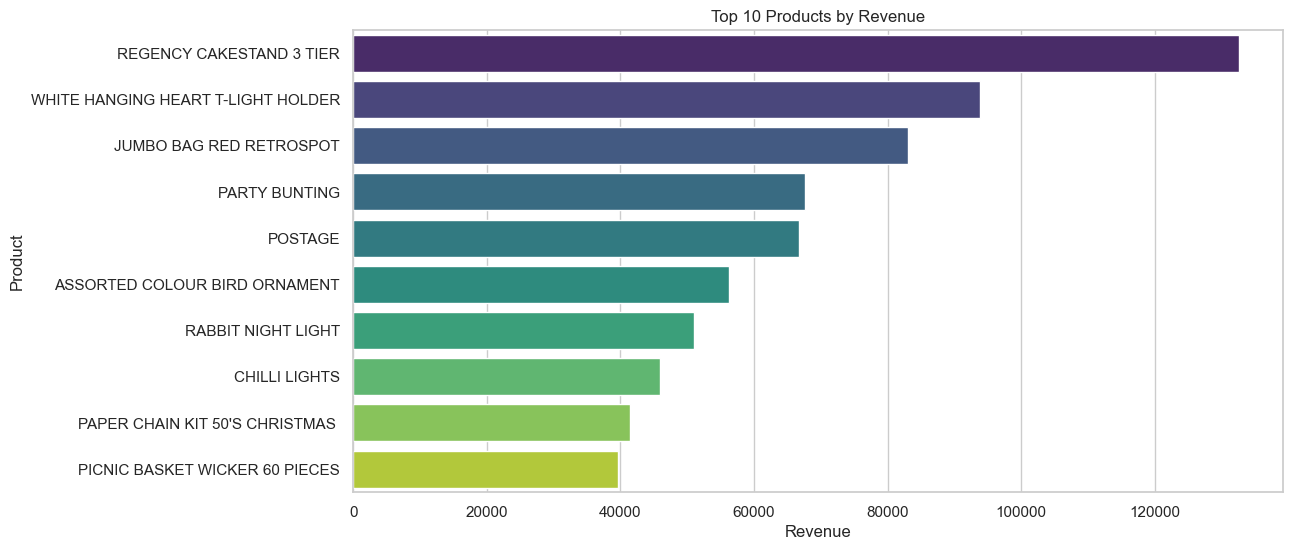

In [8]:
top_products = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10) # For each product calculate total revenue
plt.figure(figsize=(12,6))
sns.barplot(
    x=top_products.values,
    y=top_products.index,
    hue=top_products.index,
    palette="viridis",
    legend=False
)
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.show()

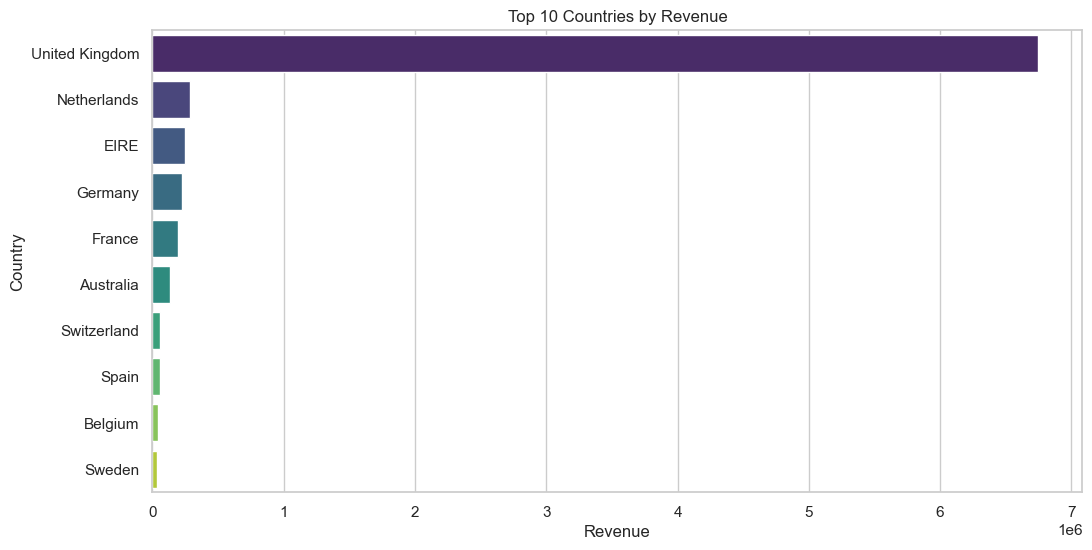

In [9]:
country_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
sns.barplot(
    x=country_revenue.values,
    y=country_revenue.index,
    hue=country_revenue.index,
    palette="viridis",
    legend=False
)
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")

plt.show()

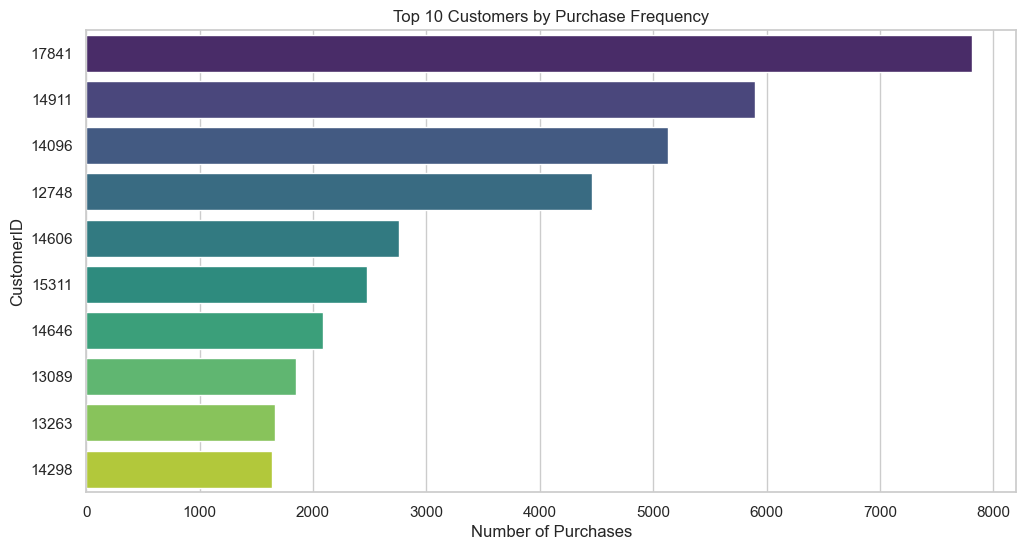

In [10]:
customer_freq = df['CustomerID'].value_counts().head(10)
plt.figure(figsize=(12,6))
sns.barplot(
    x=customer_freq.values,
    y=customer_freq.index.astype(str),
    hue=customer_freq.index.astype(str),
    palette="viridis",
    legend=False
)
plt.title("Top 10 Customers by Purchase Frequency")
plt.xlabel("Number of Purchases")
plt.ylabel("CustomerID")

plt.show()

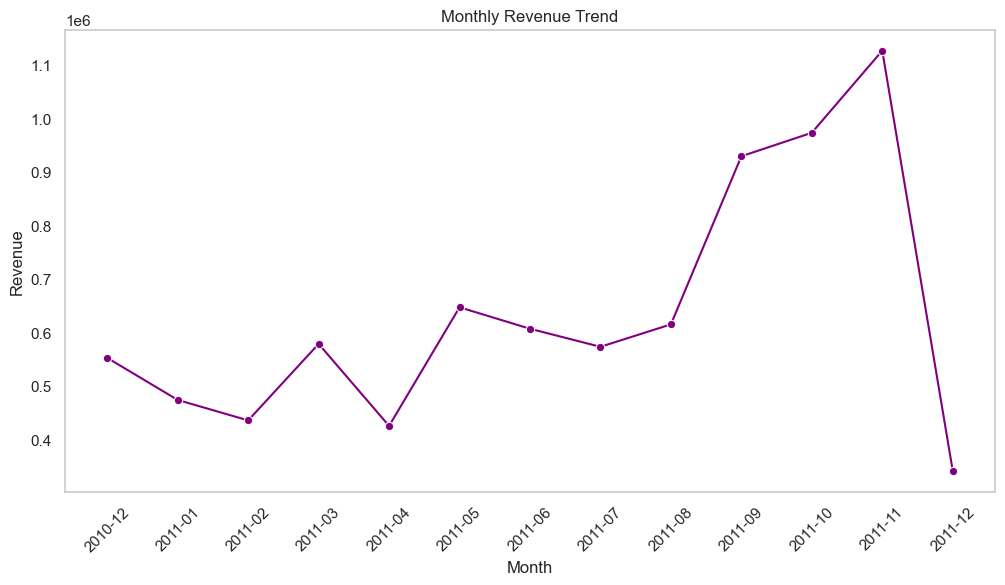

In [11]:
import seaborn as sns
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Extract Year-Month
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M').astype(str)

# Group data
monthly_revenue = df.groupby('YearMonth')['Revenue'].sum().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(
    data=monthly_revenue,
    x='YearMonth',
    y='Revenue',
    marker='o',
    color='purple'
)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(False)
plt.show()